In [1]:
###Deep Learning using Pytorch Session 5:ResNet, Regularization and Data Augumentation 

In [4]:
#ResNet : Residual Networks
#90% accuracy in less 5minutes time on single GPU

#cifar image classification by 75% accuracy using convulution neural network

#Data normalization, augumentation, residual connection, Batch normalization, learning rate scheduling
# weight decaying , gradient clipping, Adam optimizer


#Generative AI model: Random input vector (2 neural networks, Genrator and discriminator), compare the generated image with real image and then discrimniaotr model has to predict if it was actual data set or generated data set like real or fake.
#It does binary classification

In [3]:
import os
import torch
import torchvision
import tarfile
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision.datasets.utils import download_url
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
data_dir = './data/cifar10'

print(os.listdir(data_dir))
classes = os.listdir(data_dir + '/train')
print(classes)

['test', 'train']
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
##  Every class has equal number of images 
len(os.listdir(data_dir + '/train/dog'))


5000

In [9]:
# Create pytorch datasets 

# 1. Use the test set as validation set: As we have labels for the test set and guves little more data to test with.
# 2. Channel wise data normalization: 3 channels for image red green and blue and has pixels value from (0,10). Red might have hiher weightage than blue.
#Get mean of all the channels, and subtract the mean and divite by standard deviation from the channels, this gives channel pixel from -1 to 1, thus prevents any one channel dominatinght eother.
#3. Randomize data augumentation: Prevent overfitting. Images will be padded to 4 pixels and rotate it horizontally and thus epoch will see different images, thus apply this only for training images and not validation images.


In [10]:
## Data transform and Augumentation 

# chose channel wise means for red, blue green and then std deviation
stats = ((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))

#torch ttransofrm to get  normalise
train_tfms = tt.Compose([tt.RandomCrop(32, padding = 4, padding_mode='reflect'),
                        tt.RandomHorizontalFlip(),
                        tt.ToTensor(),
                        tt.Normalize(*stats, inplace=True)])
val_tfms = tt.Compose([tt.ToTensor(),tt.Normalize(*stats)])

#Normalization to both train and validation set


In [11]:
train_ds = ImageFolder(data_dir+'/train', train_tfms)
val_ds= ImageFolder(data_dir+'/test', val_tfms)

In [65]:
batch_size = 100 #max utilization og GPU memory
train_dl = DataLoader(train_ds, batch_size, shuffle= True, num_workers=3, pin_memory=True)
val_dl= DataLoader(val_ds, batch_size=2, num_workers=3, pin_memory=True)

In [66]:
def show_batch(dl):
    for images, labels in dl:
        fig,ax = plt.subplots(figsize=(12,12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:64], nrow=8).permute(1,2,0)) #shows 64 images and permute the dimesnion
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


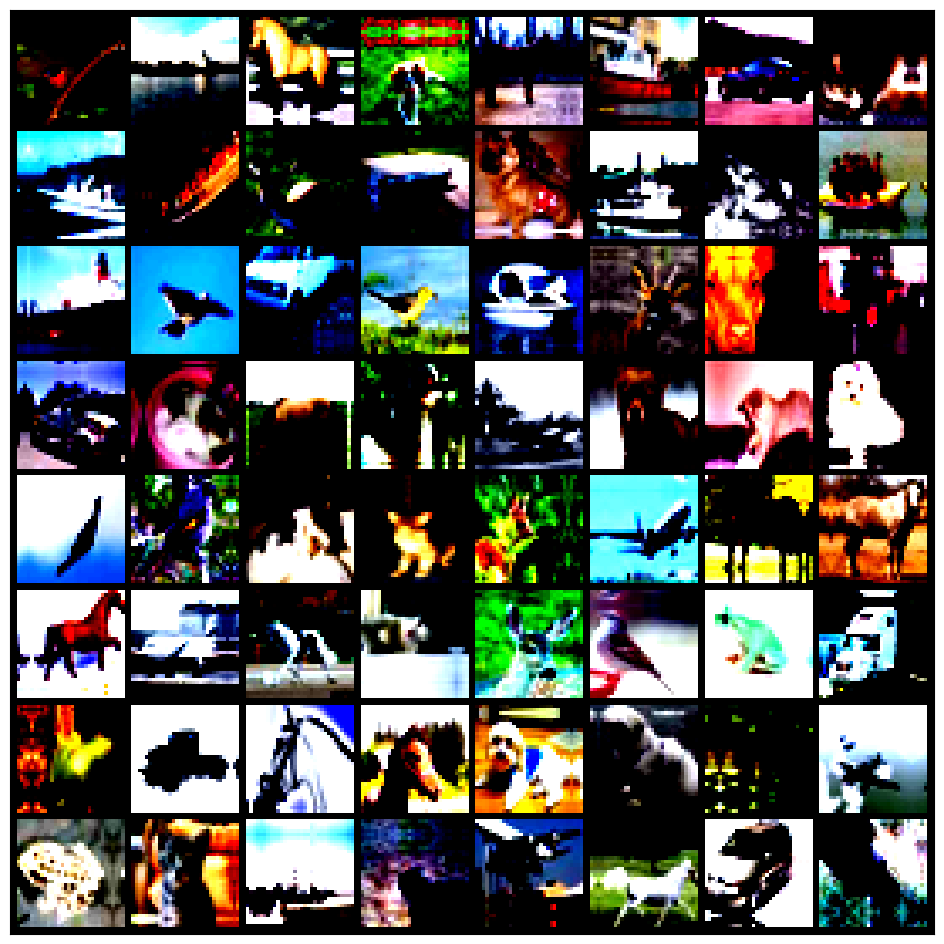

In [67]:
show_batch(train_dl)

In [68]:
## Using GPU ##

def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self,dl,device):
        self.dl=dl
        self.device=device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b,self.device)

    def __len__(self):
        return len(self.dl)
    

In [69]:
device = get_default_device()
device

device(type='cuda')

In [70]:
train_dl = DeviceDataLoader(train_dl,device)
val_dl= DeviceDataLoader(val_dl, device)

In [71]:
## Model with residual block and batch normalization ##

#Compared to CNN, here there is addition of the residual block, which adds the original input back to the output feature map by passing it through more than one convulotion layers.

# x-> weoght layer ->reLU -> weight layer ->reLU . after output we add input back thus acts as residual block.

In [72]:
class SimpleResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels= 3, kernel_size=3, stride=1, padding =1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels= 3, kernel_size=3, stride=1, padding =1)
        self.relu2 = nn.ReLU()

    def forward(self,x):
        out= self.conv1(x)
        out= self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out + x) #added the input back here therefore residual

In [73]:
simple_resnet = to_device(SimpleResidualBlock(), device)

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break

del simple_resnet, images, labels
torch.cuda.empty_cache()

torch.Size([100, 3, 32, 32])


In [74]:
#400 bacthc size, 3 channels, 32 pixels.
# drastic improvement in the performance of the model.

#residuals give input a shorter path to output; 
#h(x) = R(x)+ x
#Residual = h(x) - x 

#Batch normalization is also similar to data normalization(channels are normalized). 
# In batch normalization we normalise the activation outputs, it takes output of the layer and appliues normalization there 
# h(y) = h(x+1)-h(x)/ stad deviation


In [75]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim= 1)
    return torch.tensor(torch.sum(preds==labels).item()/len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self,batch):
        images, labels = batch
        out= self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels= batch
        out= self(images)
        loss = F.cross_entropy(out, labels)
        acc= accuracy(out, labels)
        return {'val_loss':loss.detach(), 'val_acc':acc}

    def validation_end_epoch(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_accs= torch.stack(batch_accs).mean()
        return {'val_loss':epoch_loss.item(), 'val_acc': epoch_accs.item()}

    def epoch_end(self, epoch, result):
        print('Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_ac: {:.4f}'.format(epoch, result['lrs'][-1], result['train_loss'],
                                                                                                        result['val_loss'], result['val_acc']))

In [76]:
def conv_block(in_channels,out_channels, pool= False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding = 1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace= True)]
    if pool: layers.append(nn.MaxPool2d(2)) #this will take 4 pixel and replace with single pixel, reduce the output pixel to half.
    return nn.Sequential(*layers) #Pass input through all the layers

class ResNet9(ImageClassificationBase): #this gets us to 95% accuracy
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool= True)
        self.res1 = nn.Sequential(conv_block(128,128), conv_block(128,128))

        self.conv3 = conv_block(128,256,pool=True)
        self.conv4 = conv_block(256, 512, pool= True)
        self.res2 = nn.Sequential(conv_block(512,512), conv_block(512,512))

        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_classes))

    def forward(self,xb):
        out = self.conv1(xb)
        out= self.conv2(out)
        out = self.res1(out)+ out
        out= self.conv3(out)
        out = self.conv4(out)
        out= self.res2(out) + out
        out= self.classifier(out)
        return out #remove addition of out and check again

model = to_device(ResNet9(3,10), device)
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

In [77]:
## Training the model ##

# model is organized now.

#Data normalization. data augumentation and residual networks are done. Next is learning rate scheduling. Change learning rate after every batch.

# Start with larger learning rate and then change the learning rate. Can be done step wise or cycle wise.
# 1cycle policy : incease to the peak and then decrease the lr. 

#Weight decay: None of the weight should become very large as they dispropotiante the gradients. thus add a term to loss.
# add sum of weight square to loss and update the weight 

#Gardient clipping: In back propogation gradients will be too large thus to prevent we use gradient clipping.


In [78]:
@torch.no_grad()

def evaluate(model, val_loader):
    model.eval()
    outputs= [model.validation_step(batch) for batch in val_loader]
    return model.validation_end_epoch(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                 weight_decay=0, grad_clip= None, opt_func= torch.optim.SGD):
    torch.cuda.empty_cache()
    history=[]

    optimizer= opt_func(model.parameters(),max_lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                               steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        model.train()
        train_losses=[]
        lrs=[]
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            lrs.append(get_lr(optimizer))
            sched.step()

        result= evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [79]:
history= [evaluate(model, val_dl)]
history

[{'val_loss': 2.3058929443359375, 'val_acc': 0.09120000153779984}]

In [80]:
epochs = 8
max_lr = 0.01
grad_clip =0.1
weight_decay = 1e-4
opt_func =torch.optim.SGD

In [81]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, val_dl, grad_clip= grad_clip,
                        weight_decay= weight_decay, opt_func= opt_func)

OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 31.74 MiB is free. Of the allocated memory 842.04 MiB is allocated by PyTorch, and 109.96 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [82]:
## The accuracy increases to 90% comapred to CNN of 75%, 95% accuracy in 5minute is very hard.

def plot_accuracies(history):
    accuracies =[x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs No of epochs')

def plot_lrs(history):
    lrs= np.concatenate([x.get('lrs',[]) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no')
    plt.ylabel('Learning rate')
    plt.title('Lr vs Batch no')

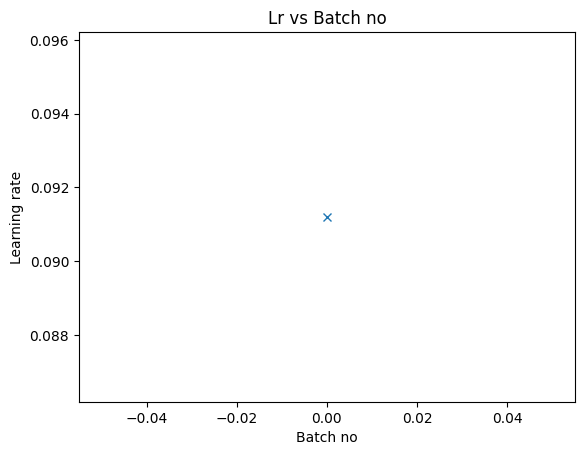

In [83]:
plot_accuracies(history)
plot_lrs(history)

In [84]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [85]:
torch.cuda.memory_summary()

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 20           |        cudaMalloc retries: 24        |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      | 202633 KiB |   1725 MiB |   5028 GiB |   5027 GiB |\n|       from large pool | 198080 KiB |   1711 MiB |   4667 GiB |   4667 GiB |\n|       from small pool |   4553 KiB |     18 MiB |    360 GiB |    360 GiB |\n|---------------------------------------------------------------------------|\n| Active memory         | 202633 KiB |   1725 MiB |   5028 GiB |   5027 GiB |\n|       from large pool | 198080 KiB |   1711 MiB |

In [ ]:
## 